# Outlaws of Thunder Junction Analysis

#### Outlaws of Thunder Junction Meta | Magic: The Gathering Card Ratings
#### Dataset: https://www.kaggle.com/datasets/darrylljk/magic-the-gathering-card-ratings-otj?resource=download

Description

In [100]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [102]:
#load dataset
df = pd.read_csv('dataset/MTG-OTJ-draft-card-ratings-2024-05-25.csv')

In [104]:
#view summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 376 entries, 0 to 375
Data columns (total 19 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      376 non-null    object 
 1   Color     330 non-null    object 
 2   Rarity    376 non-null    object 
 3   # Seen    376 non-null    int64  
 4   ALSA      376 non-null    float64
 5   # Picked  376 non-null    int64  
 6   ATA       375 non-null    float64
 7   # GP      376 non-null    int64  
 8   % GP      376 non-null    object 
 9   GP WR     368 non-null    object 
 10  # OH      376 non-null    int64  
 11  OH WR     345 non-null    object 
 12  # GD      376 non-null    int64  
 13  GD WR     353 non-null    object 
 14  # GIH     376 non-null    int64  
 15  GIH WR    360 non-null    object 
 16  # GNS     376 non-null    int64  
 17  GNS WR    364 non-null    object 
 18  IWD       360 non-null    object 
dtypes: float64(2), int64(7), object(10)
memory usage: 55.9+ KB


In [106]:
#view head
df.head()

,Name,Color,Rarity,# Seen,ALSA,# Picked,ATA,# GP,% GP,GP WR,# OH,OH WR,# GD,GD WR,# GIH,GIH WR,# GNS,GNS WR,IWD
0,Another Round,W,R,64972,6.27,7953,9.59,1690,3.6%,46.6%,259,NaN,402,NaN,661,40.4%,1029,50.6%,-10.2pp
1,Archangel of Tithes,W,M,9905,2.08,3697,2.15,18171,82.7%,53.9%,2952,54.6%,4325,55.8%,7277,55.3%,10927,52.9%,2.4pp
2,Armored Armadillo,W,C,378941,7.89,40803,11.61,31423,12.9%,51.0%,5421,50.0%,7265,50.8%,12686,50.4%,18704,51.3%,-0.9pp
3,Aven Interrupter,W,R,24080,2.42,8609,2.64,44852,86.6%,55.5%,7735,56.6%,10692,57.5%,18427,57.1%,26391,54.3%,2.8pp
4,Bounding Felidar,W,U,98493,4.11,18079,5.53,86683,80.2%,54.6%,13034,53.6%,20093,55.4%,33127,54.7%,52462,54.4%,0.3pp


In [108]:
#check for missing values by column
df.isnull().sum()

Name         0
Color       46
Rarity       0
# Seen       0
ALSA         0
# Picked     0
ATA          1
# GP         0
% GP         0
GP WR        8
# OH         0
OH WR       31
# GD         0
GD WR       23
# GIH        0
GIH WR      16
# GNS        0
GNS WR      12
IWD         16
dtype: int64

<Axes: >

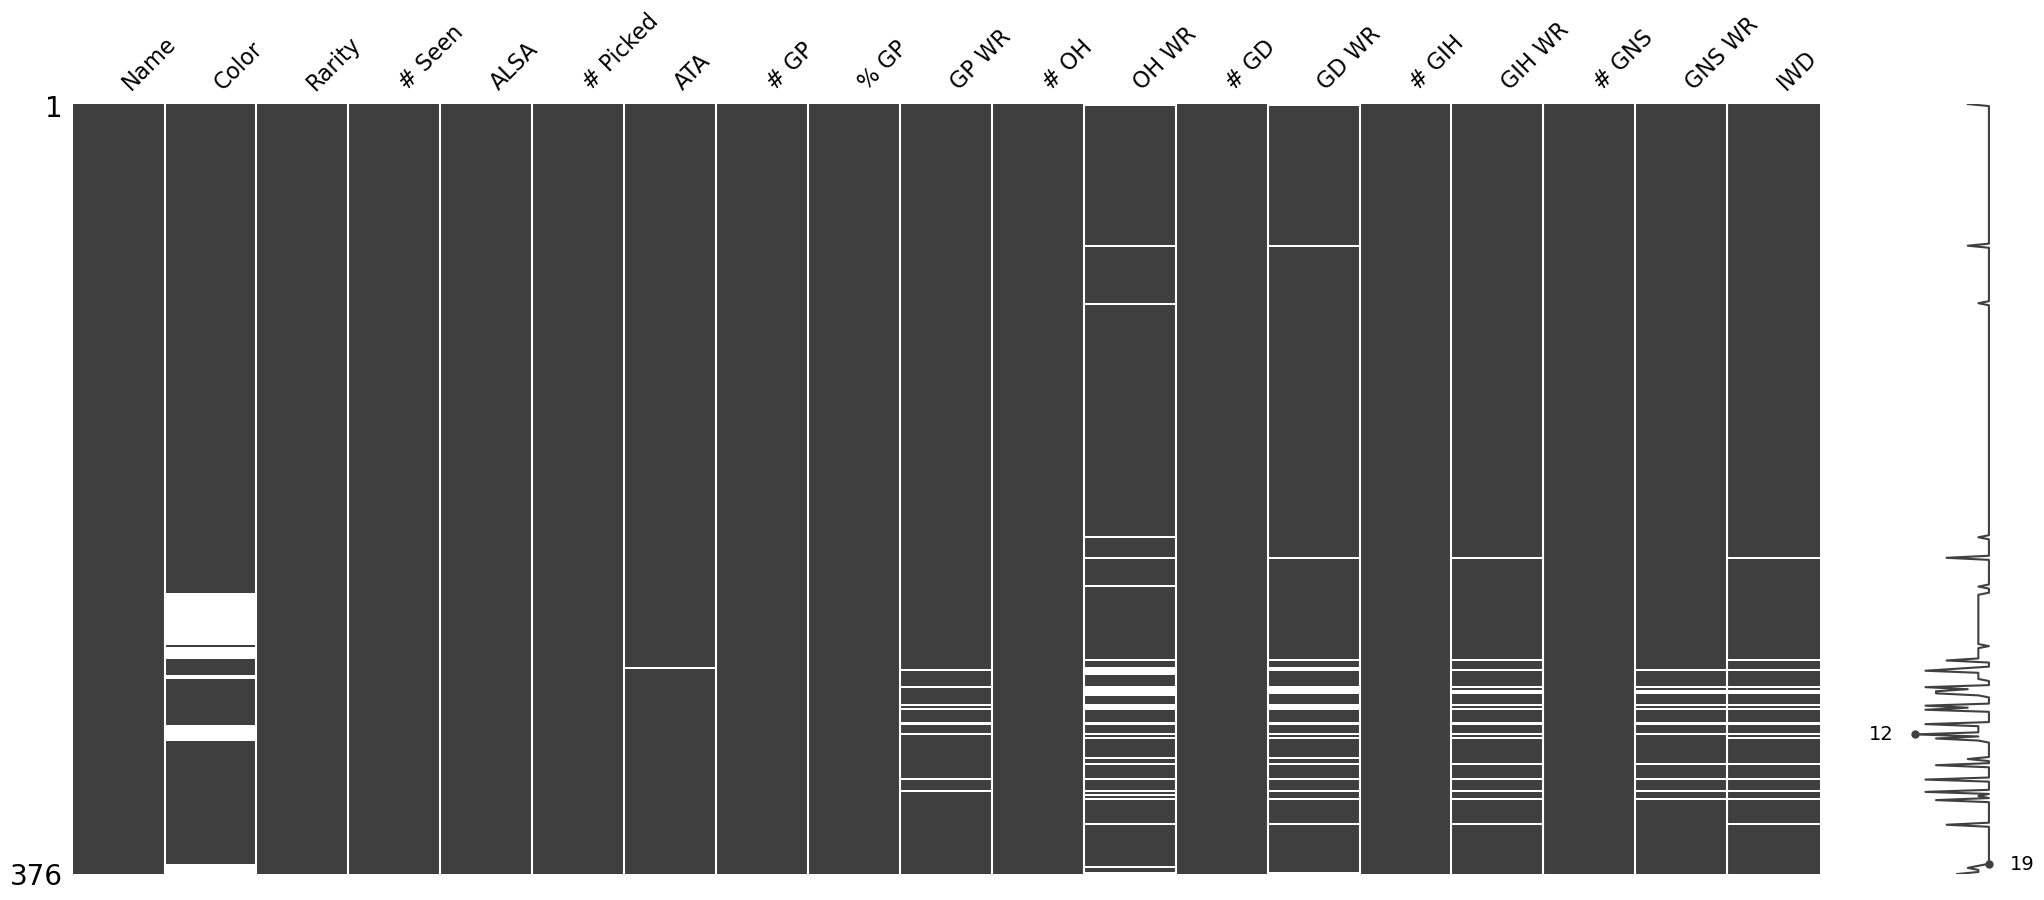

In [110]:
#check for missing value distribution
import missingno as msno
msno.matrix(df)

In [112]:
#create list of cards with null values for 'Color'
df[df['Color'].isnull()]

,Name,Color,Rarity,# Seen,ALSA,# Picked,ATA,# GP,% GP,GP WR,# OH,OH WR,# GD,GD WR,# GIH,GIH WR,# GNS,GNS WR,IWD
239,Bandit's Haul,NaN,U,129911,5.44,22108,7.34,82856,63.2%,53.0%,15147,53.3%,21464,54.1%,36611,53.7%,46122,52.3%,1.4pp
240,Boom Box,NaN,U,157524,7.71,17591,11.40,9248,8.9%,51.1%,1469,47.8%,2385,52.8%,3854,50.9%,5372,51.3%,-0.4pp
241,Gold Pan,NaN,C,380819,7.59,46768,11.00,60891,21.8%,52.5%,11002,53.5%,13725,51.4%,24727,52.3%,35979,52.6%,-0.3pp
242,Lavaspur Boots,NaN,U,152968,7.32,15203,11.17,10933,12.1%,53.3%,1802,53.6%,2412,50.7%,4214,51.9%,6702,54.1%,-2.2pp
243,Luxurious Locomotive,NaN,U,153700,7.21,17438,10.76,18406,17.7%,50.8%,2832,48.0%,4475,50.4%,7307,49.5%,11106,51.7%,-2.3pp
244,Mobile Homestead,NaN,U,118895,4.77,23457,6.42,104882,73.8%,55.4%,19121,58.6%,23610,53.8%,42731,55.9%,62106,55.1%,0.9pp
245,Oasis Gardener,NaN,C,354784,6.18,50857,8.99,171480,56.7%,53.2%,30948,53.1%,41731,54.4%,72679,53.9%,98417,52.6%,1.2pp
246,Redrock Sentinel,NaN,U,150233,6.77,23193,9.53,65552,47.3%,53.9%,11424,52.3%,16533,55.9%,27957,54.4%,37479,53.4%,1.0pp
247,Silver Deputy,NaN,C,368473,6.85,46880,9.99,114152,41.4%,51.2%,21639,49.2%,26618,50.6%,48257,49.9%,65653,52.1%,-2.2pp
248,Sterling Hound,NaN,C,383024,7.63,54473,10.78,104287,32.1%,53.4%,18563,52.4%,25113,54.1%,43676,53.4%,60445,53.4%,-0.1pp


These cards all appear to be lands or artifacts, which are technically "colorless" cards.

In [116]:
#drop null values from 'GP WR' and 'OH WR'
df.dropna(subset=['GP WR'], inplace=True)
df.dropna(subset=['OH WR'], inplace=True)

In [118]:
#convert 'GP WR' and 'OH WR' to float
cols = ['GP WR','OH WR']

df[cols] = (
    df[cols]
      .replace('%','',regex=True)
      .apply(pd.to_numeric, errors='coerce')
      .div(100)
)

In [120]:
#sort by win rate
df_sorted = df.sort_values('GP WR', ascending=False)

#pick top 10 cards
top10 = df_sorted.head(10)

#display card name, win rate, rarity and color
print(top10[['Name', 'GP WR', 'Rarity', 'Color']])

                          Name  GP WR Rarity Color
174            Railway Brawler  0.580      M     G
156  Bristly Bill, Spine Sower  0.580      M     G
300           Vaultborn Tyrant  0.579      M     G
281           Collector's Cage  0.577      M     W
297          Bristlebud Farmer  0.576      M     G
231             Seraphic Steed  0.576      R    WG
170          Ornery Tumblewagg  0.575      R     G
171       Outcaster Greenblade  0.575      U     G
195    Bonny Pall, Clearcutter  0.574      R    UG
227   Roxanne, Starfall Savant  0.574      R    RG


In [122]:
#filter out mythic and rare cards
df_filtered = df.loc[~df['Rarity'].isin(['M', 'R'])].copy()

#pick top 10 uncommon and common cards
top10_uc = (
    df_filtered
      .sort_values('GP WR', ascending=False)
      .head(10)
)

#display card names, win rate, rarity and color
print(top10_uc[['Name', 'GP WR', 'Rarity', 'Color']])

                       Name  GP WR Rarity Color
171    Outcaster Greenblade  0.575      U     G
220  Miriam, Herd Whisperer  0.572      U    WG
17       Lassoed by the Law  0.572      U     W
199      Congregation Gryff  0.571      U    WG
181    Spinewoods Armadillo  0.571      U     G
12          Frontier Seeker  0.568      U     W
348    Buried in the Garden  0.567      U    WG
153     Beastbond Outcaster  0.567      U     G
265           Bucolic Ranch  0.567      U   NaN
184   Throw from the Saddle  0.567      C     G


In [124]:
#exclude green cards
df_non_green = df[df['Color'] != 'G'].copy()

#pick top 10 non green cards
top10_non_green = (
    df_non_green
      .sort_values('GP WR', ascending=False)
      .head(10)
)

#display results
print(top10_non_green[['Name', 'GP WR', 'Rarity', 'Color']])

                         Name  GP WR Rarity Color
281          Collector's Cage  0.577      M     W
231            Seraphic Steed  0.576      R    WG
327       Overwhelming Forces  0.574      M     B
227  Roxanne, Starfall Savant  0.574      R    RG
195   Bonny Pall, Clearcutter  0.574      R    UG
220    Miriam, Herd Whisperer  0.572      U    WG
17         Lassoed by the Law  0.572      U     W
199        Congregation Gryff  0.571      U    WG
290      Hostile Investigator  0.570      M     B
360      Oko, Thief of Crowns  0.569      M    UG


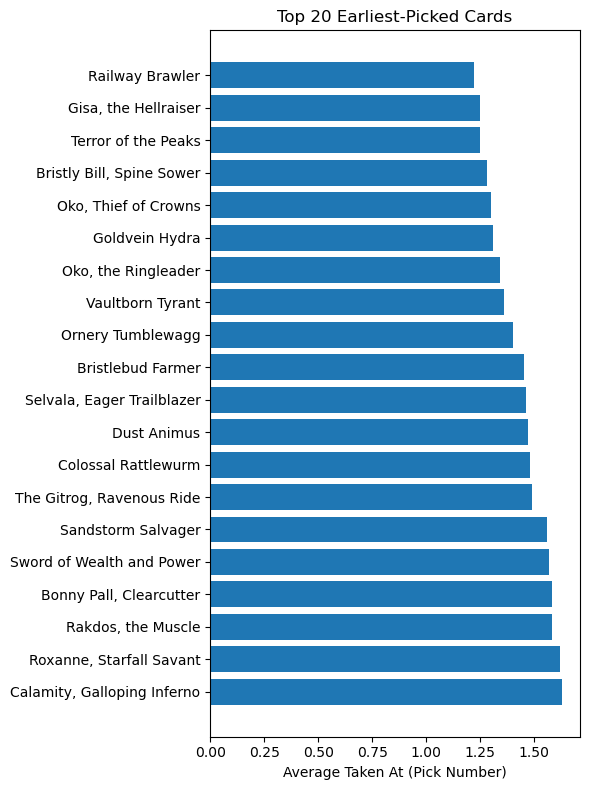

In [126]:
low_ata = df.nsmallest(20, 'ATA')

plt.figure(figsize=(6, 8))
plt.barh(low_ata['Name'], low_ata['ATA'])
plt.xlabel('Average Taken At (Pick Number)')
plt.title('Top 20 Earliest‐Picked Cards')
plt.gca().invert_yaxis()  # so the lowest ATA is at the top
plt.tight_layout()
plt.show()

In [128]:
#create thresholds
ata_thresh = df['ATA'].quantile(0.10)     # e.g. the 10% earliest-taken cards
wr_thresh  = df['GP WR'].quantile(0.75)   # top 25% in win-rate

#filter must picks
must_picks = df[
    (df['ATA'] <= ata_thresh) &
    (df['GP WR'] >= wr_thresh)
].copy()

#sort
must_picks = must_picks.sort_values(['ATA', 'GP WR'])

#print results
print(must_picks[['Name', 'Color', 'Rarity', 'ATA', 'GP WR']])

                           Name Color Rarity   ATA  GP WR
174             Railway Brawler     G      M  1.22  0.580
88         Gisa, the Hellraiser     B      M  1.25  0.555
156   Bristly Bill, Spine Sower     G      M  1.28  0.580
360        Oko, Thief of Crowns    UG      M  1.30  0.569
166              Goldvein Hydra     G      M  1.31  0.559
300            Vaultborn Tyrant     G      M  1.36  0.579
170           Ornery Tumblewagg     G      R  1.40  0.575
297           Bristlebud Farmer     G      M  1.45  0.576
230  Selvala, Eager Trailblazer    WG      M  1.46  0.564
8                   Dust Animus     W      R  1.47  0.567
158         Colossal Rattlewurm     G      R  1.48  0.567
205   The Gitrog, Ravenous Ride    BG      M  1.49  0.556
299          Sandstorm Salvager     G      M  1.56  0.571
225          Rakdos, the Muscle    BR      M  1.58  0.562
195     Bonny Pall, Clearcutter    UG      R  1.58  0.574
227    Roxanne, Starfall Savant    RG      R  1.62  0.574
172       Outc

In [130]:
df['Pick Rate'] = df['# Picked'] / df['# Seen']

#compute median thresholds
pr_med  = df['Pick Rate'].median()    # table’s “typical” pick-rate
ata_med = df['ATA'].median()          # table’s “typical” pick timing
wr_med  = df['GP WR'].median()        # table’s “typical” win-rate

#filter for undervalued picks
undervalued = df[
    (df['Pick Rate'] <  pr_med) & 
    (df['ATA']       <  ata_med) & 
    (df['GP WR']     >  wr_med)       
].copy()

#sort so your best opportunities bubble up
undervalued = undervalued.sort_values(
    by=['GP WR','ATA'], 
    ascending=[False, True]
)

#print results
print(
    undervalued[
        ['Name','Color','Rarity','Pick Rate','ATA','GP WR']
    ].head(15)
)

                    Name Color Rarity  Pick Rate   ATA  GP WR
4       Bounding Felidar     W      U   0.183556  5.53  0.546
312   Fierce Retribution     W      U   0.168160  5.58  0.538
117       Cunning Coyote     R      U   0.177495  5.71  0.538
269    Inspiring Vantage   NaN      R   0.155593  5.84  0.537
268  Concealed Courtyard   NaN      R   0.167869  5.89  0.537


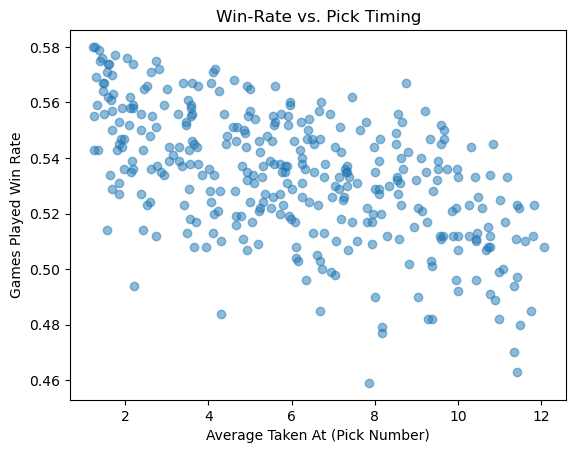

In [132]:
plt.scatter(df['ATA'], df['GP WR'], alpha=0.5)
plt.xlabel('Average Taken At (Pick Number)')
plt.ylabel('Games Played Win Rate')
plt.title('Win-Rate vs. Pick Timing')
plt.show()

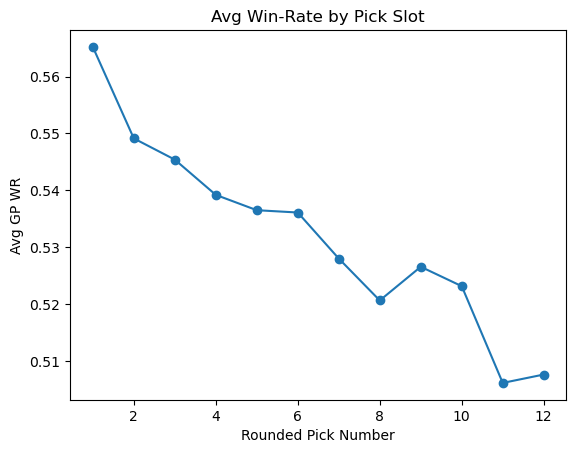

In [134]:
df['PickBin'] = df['ATA'].round().astype(int)
summary = df.groupby('PickBin')['GP WR'].mean().reset_index()

plt.plot(summary['PickBin'], summary['GP WR'], marker='o')
plt.xlabel('Rounded Pick Number')
plt.ylabel('Avg GP WR')
plt.title('Avg Win-Rate by Pick Slot')
plt.show()

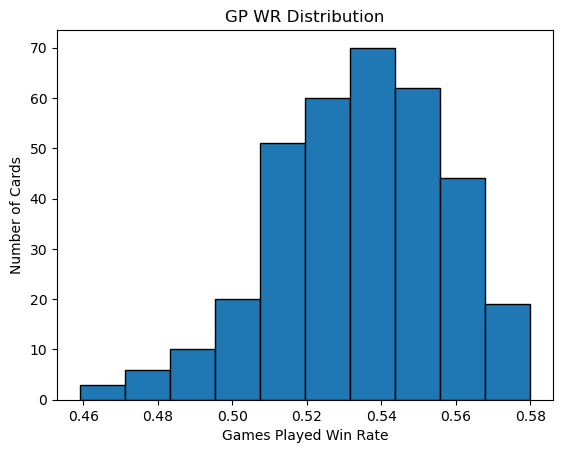

In [136]:
plt.hist(df['GP WR'], bins=10, edgecolor='black')
plt.xlabel('Games Played Win Rate')
plt.ylabel('Number of Cards')
plt.title('GP WR Distribution')
plt.show()

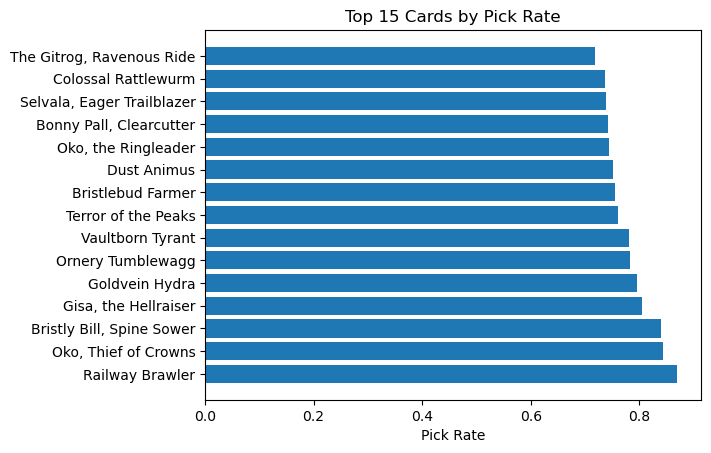

In [138]:
N = 15
top_picks = df.nlargest(N, 'Pick Rate').sort_values('Pick Rate')

plt.barh(top_picks['Name'], top_picks['Pick Rate'])
plt.xlabel('Pick Rate')
plt.title(f'Top {N} Cards by Pick Rate')
plt.gca().invert_yaxis()
plt.show()

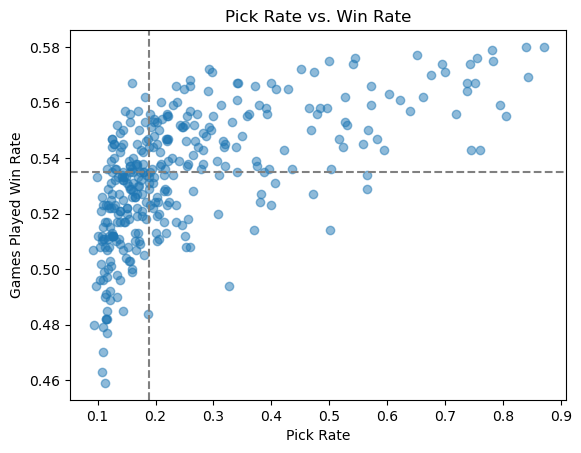

In [140]:
plt.scatter(df['Pick Rate'], df['GP WR'], alpha=0.5)
plt.axvline(df['Pick Rate'].median(), linestyle='--', color='grey')
plt.axhline(df['GP WR'].median(),    linestyle='--', color='grey')
plt.xlabel('Pick Rate')
plt.ylabel('Games Played Win Rate')
plt.title('Pick Rate vs. Win Rate')
plt.show()

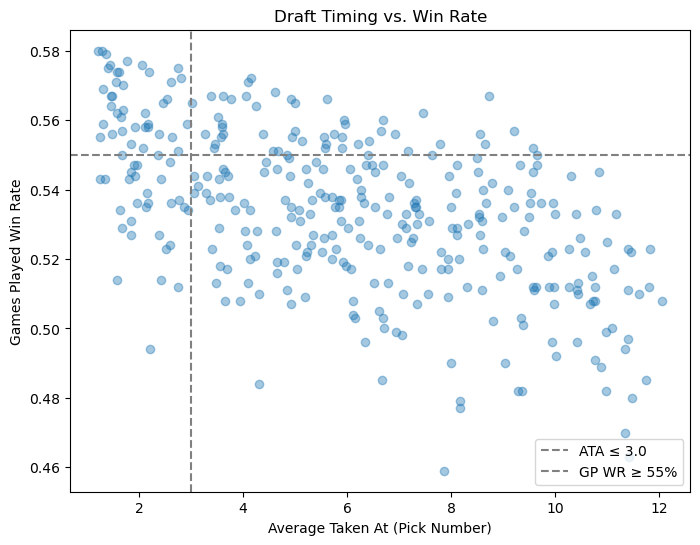

In [142]:
# thresholds
ata_cut = df['ATA'].quantile(0.20)
wr_cut  = df['GP WR'].quantile(0.75)

plt.figure(figsize=(8,6))
plt.scatter(df['ATA'], df['GP WR'], alpha=0.4)

# quadrant lines
plt.axvline(ata_cut, linestyle='--', color='grey', label=f'ATA ≤ {ata_cut:.1f}')
plt.axhline(wr_cut,  linestyle='--', color='grey', label=f'GP WR ≥ {wr_cut:.0%}')

plt.xlabel('Average Taken At (Pick Number)')
plt.ylabel('Games Played Win Rate')
plt.title('Draft Timing vs. Win Rate')
plt.legend(loc='lower right')
plt.savefig('draft_timing_vs_winrate.png', dpi=300, bbox_inches='tight')
plt.show()


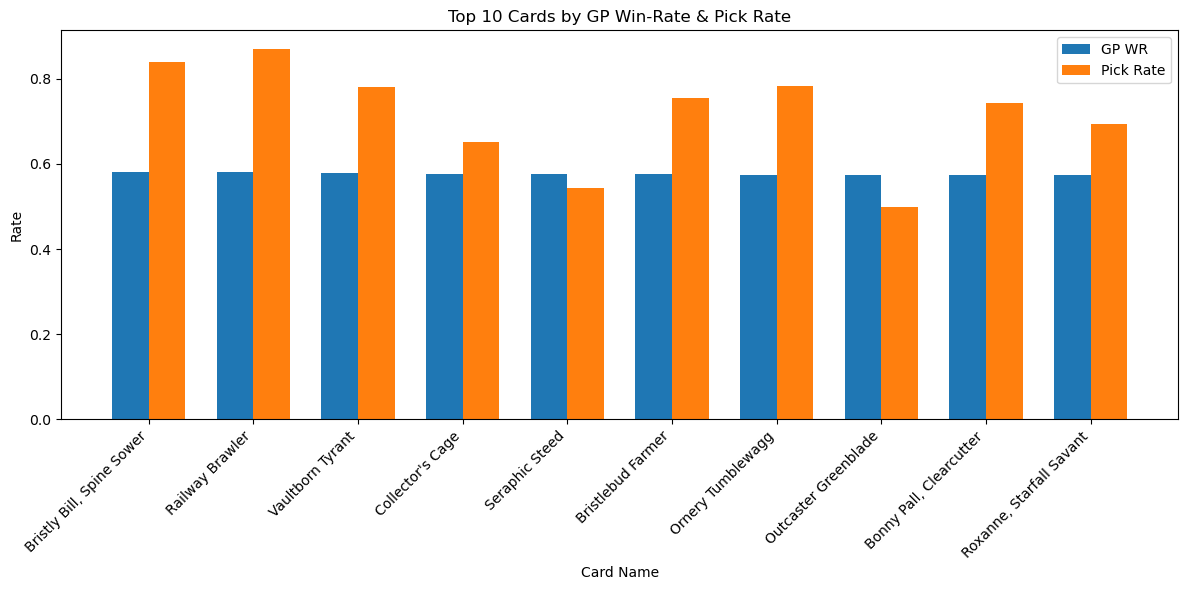

In [144]:
if 'Pick Rate' not in df.columns:
    df['Pick Rate'] = df['Number Picked'] / df['Number Seen']

top10 = df.nlargest(10, 'GP WR').sort_values('GP WR', ascending=False)

labels    = top10['Name']
win_rates = top10['GP WR']
pick_rates= top10['Pick Rate']

x     = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, win_rates,  width, label='GP WR')
ax.bar(x + width/2, pick_rates, width, label='Pick Rate')

ax.set_xlabel('Card Name')
ax.set_ylabel('Rate')
ax.set_title('Top 10 Cards by GP Win-Rate & Pick Rate')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.legend()
fig.tight_layout()

fig.savefig('top10_winrate_pickrate.png', dpi=300, bbox_inches='tight')


plt.show()

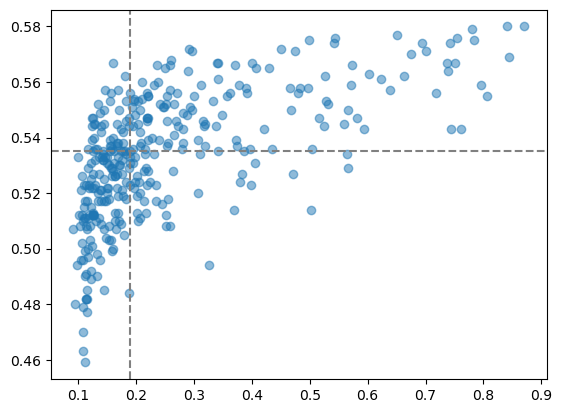

In [148]:
plt.scatter(df['Pick Rate'], df['GP WR'], alpha=0.5)
plt.axvline(df['Pick Rate'].median(), linestyle='--', color='grey')
plt.axhline(df['GP WR'].median(),    linestyle='--', color='grey')